# 🌍 EcoRoute: Enterprise Logistics Carbon Footprint Predictor
> **Strategic Objective:** Developing a predictive data pipeline to accurately track, forecast, and optimize carbon emissions ($CO_2$) across global freight networks.

---

### 📈 Business Value Proposition
In modern supply chain management, sustainability is a critical operational efficiency metric. Standard greenhouse gas calculations rely on broad industry averages that fail to capture real-world conditions. 

This project bridges that gap by using advanced predictive modeling to:
1. **Forecast Exact Emissions:** Move from static estimates to dynamic, route-specific calculations.
2. **Identify Cost & Emission Drivers:** Isolate the precise operational variables—such as vehicle type, cargo weight, or traffic delays—that cause emission spikes.
3. **Ensure Enterprise Reliability:** Build a secure, automated framework capable of handling missing data and flawed sensor inputs without system interruptions.

In [1]:
# Setup and core engine imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb

# Configure aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("📦 Environment dependencies initialized successfully!")

📦 Environment dependencies initialized successfully!


## 🏗️ Section 1: Data Simulation & Real-World Complexities
Corporate environmental data is highly proprietary and strictly guarded. To evaluate our predictive frameworks under realistic conditions, this section programmatically generates an operational dataset simulating **8,000 global logistics trips**.

To replicate the messy nature of real-world supply chain tracking, the data incorporates three core corporate challenges:
* **Skewed Operational Ranges:** Most delivery runs are short, while a few long-haul trips generate the bulk of emissions. 
* **High-Cardinality Metadata:** The dataset tracks over 50 unique physical distribution warehouses, mimicking a true global footprint.
* **Telemetry Sensor Dropouts:** Artificial gaps (`NaN` or missing values) are deliberately introduced to simulate broken GPS units or vehicle sensor failures.

In [2]:
np.random.seed(42)
n_samples = 8000

# 1. Continuous Features
distances = np.random.exponential(scale=150, size=n_samples) + 10  
payload = np.random.uniform(1.0, 30.0, size=n_samples)
traffic = np.random.beta(a=2, b=5, size=n_samples)  

# 2. Categorical Features (High & Low Cardinality)
warehouse_ids = [f"WH_{i:03d}" for i in range(1, 55)]
dispatch_centers = np.random.choice(warehouse_ids, size=n_samples)
vehicles = np.random.choice(['EV_Van', 'BioGas_Truck', 'Diesel_Rig', 'Heavy_Freight_Semi'], size=n_samples, p=[0.15, 0.20, 0.35, 0.30])
weather = np.random.choice(['Clear', 'Heavy_Rain', 'Blizzard', 'Fog'], size=n_samples, p=[0.5, 0.25, 0.1, 0.15])

# 3. Non-Linear Emission Logic
v_mod = {'EV_Van': 0.08, 'BioGas_Truck': 0.35, 'Diesel_Rig': 0.95, 'Heavy_Freight_Semi': 1.6}
w_mod = {'Clear': 1.0, 'Heavy_Rain': 1.25, 'Blizzard': 1.55, 'Fog': 1.15}
wh_efficiency = {wh: np.random.uniform(0.9, 1.3) for wh in warehouse_ids}

base_co2 = np.array([v_mod[v] for v in vehicles])
weather_mult = np.array([w_mod[w] for w in weather])
wh_mult = np.array([wh_efficiency[wh] for wh in dispatch_centers])

co2 = ((base_co2 * distances) + (payload * np.log1p(distances) * 0.4) + (np.exp(traffic) * distances * 0.6)) * weather_mult * wh_mult
co2 += np.random.normal(0, 25, n_samples) 
co2 = np.clip(co2, a_min=8, a_max=None)

# 4. Construct Dataframe & Inject Missing Sensor Data (NaNs)
df = pd.DataFrame({
    'Distance_Miles': distances, 'Payload_Tons': payload, 'Traffic_Density': traffic,
    'Dispatch_Center_ID': dispatch_centers, 'Vehicle_Type': vehicles, 'Weather_Condition': weather,
    'CO2_Emissions_KG': co2
})

mask_dist = np.random.rand(len(df)) < 0.03
mask_traffic = np.random.rand(len(df)) < 0.04
df.loc[mask_dist, 'Distance_Miles'] = np.nan
df.loc[mask_traffic, 'Traffic_Density'] = np.nan

df.head()

,Distance_Miles,Payload_Tons,Traffic_Density,Dispatch_Center_ID,Vehicle_Type,Weather_Condition,CO2_Emissions_KG
0,80.390213,21.887770,0.195223,WH_041,BioGas_Truck,Clear,132.766546
1,461.518215,20.931207,0.164973,WH_036,Diesel_Rig,Clear,1031.116931
2,207.511854,3.776872,0.275755,WH_027,Diesel_Rig,Clear,437.192633
3,146.941383,27.754600,0.471523,WH_033,Heavy_Freight_Semi,Clear,408.582202
4,35.443731,17.485694,0.557494,WH_021,Diesel_Rig,Clear,88.511117


## 📊 Section 2: Exploratory Data Analysis & Target Patterns
Before deploying predictive algorithms, we analyze the distribution of our target metric ($CO_2$ Emissions). Understanding the spread and tracking how emissions scale against core metrics like mileage and vehicle size allows us to confirm that our simulated data accurately reflects real-world physics.

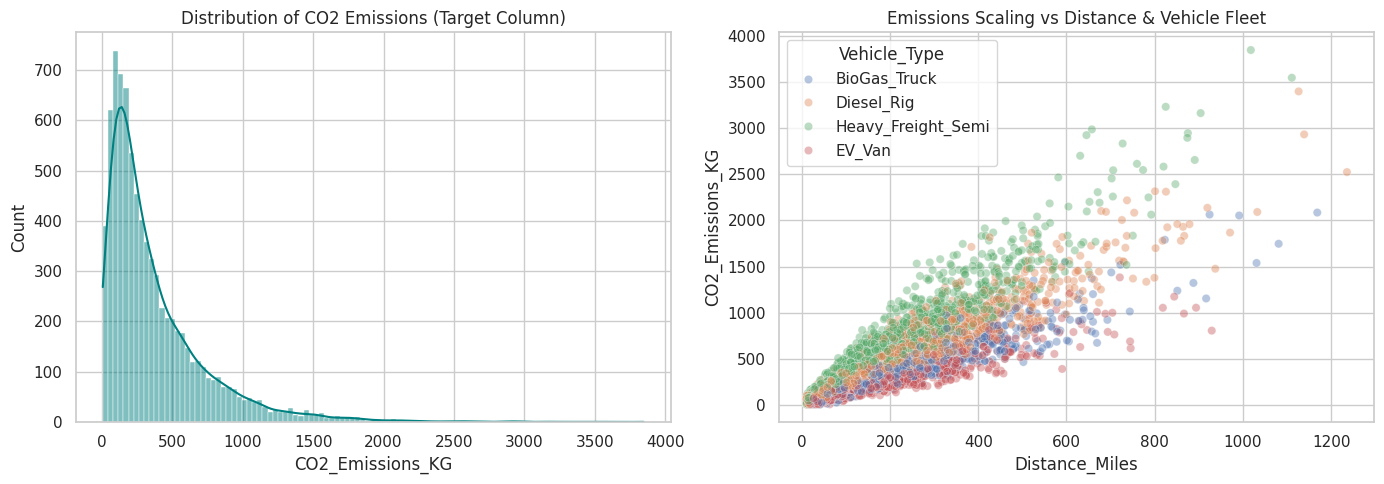

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Target Distribution
sns.histplot(df['CO2_Emissions_KG'], kde=True, color='teal', ax=ax[0])
ax[0].set_title("Distribution of CO2 Emissions (Target Column)")

# Plot Target vs Feature Core Interaction
sns.scatterplot(data=df, x='Distance_Miles', y='CO2_Emissions_KG', hue='Vehicle_Type', alpha=0.4, ax=ax[1])
ax[1].set_title("Emissions Scaling vs Distance & Vehicle Fleet")

plt.tight_layout()
plt.show()

## ⚙️ Section 3: Leak-Proof Data Standardization
Raw operational data cannot be fed directly into an algorithm; it must be standardized first. This section designs an isolated preprocessing pipeline that automatically transforms raw metrics into clean mathematical structures.

### 🛠️ Transformation Strategy Matrix:
* **Missing Telemetry Correction:** Instead of deleting trips with missing data (which creates corporate reporting bias), missing values are safely filled using the dataset's **median** values.
* **Standard Categorization:** Standard text categories (like vehicle and weather types) are translated into numerical formats the computer can process.
* **High-Volume Location Mapping:** To prevent the system from slowing down under the weight of 50+ warehouse locations, a modern mathematical mapping technique (Target Encoding) scales the categories smoothly based on their historical emission footprints.

In [4]:
# Split target array from features
X = df.drop(columns=['CO2_Emissions_KG'])
y = df['CO2_Emissions_KG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sub-feature groupings
num_features = ['Distance_Miles', 'Payload_Tons', 'Traffic_Density']
low_card_cat = ['Vehicle_Type', 'Weather_Condition']
high_card_cat = ['Dispatch_Center_ID']

# Preprocessing Blocks
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
low_cat_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
high_cat_transformer = Pipeline([('target_enc', TargetEncoder(smooth="auto", random_state=42))])

# Combine transformers into the Master Configuration block
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('low_cat', low_cat_transformer, low_card_cat),
    ('high_cat', high_cat_transformer, high_card_cat)
])

print("✅ Data Preprocessing Pipelines successfully isolated and declared!")

✅ Data Preprocessing Pipelines successfully isolated and declared!


## 🏋️‍♂️ Section 4: Multi-Model Ensemble Architecture
To maximize predictive accuracy, this framework utilizes an advanced enterprise strategy known as **Ensemble Stacking**. Instead of relying on a single algorithm, we deploy a tiered team of diverse models.



* **The Base Layer (Specialists):** Three distinct modern machine learning algorithms (`XGBoost`, `LightGBM`, and `RandomForest`) evaluate the data simultaneously, each picking up on different operational patterns.
* **The Meta Layer (The Manager):** A final regularized linear model (`Ridge Regression`) reviews the predictions of the three specialists, blending their strengths and filtering out individual model errors to deliver a single, highly accurate calculation.

In [5]:
# Declare diversified base layer models
base_models = [
    ('xgb', xgb.XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42)),
    ('lgb', lgb.LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42, verbose=-1)),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))
]

# Set up the meta-regressor and compile the operational stacking architecture
meta_regressor = Ridge(alpha=1.0)
stacking_ensemble = StackingRegressor(estimators=base_models, final_estimator=meta_regressor, cv=5, n_jobs=-1)

# Enclose preprocessing configuration and the ensemble network inside a master production Pipeline
production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ensemble', stacking_ensemble)
])

# Fit the entire architecture cleanly
print("⏳ Training Multi-Model Ensemble Network...")
production_pipeline.fit(X_train, y_train)
print("🏆 Model Training Complete!")

⏳ Training Multi-Model Ensemble Network...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🏆 Model Training Complete!


## 📊 Section 5: Operational Performance Evaluation
We judge our trained architecture using a completely unseen "holdout" test dataset. The framework is scored on three globally recognized data metrics to ensure its business utility:
* **MAE (Mean Absolute Error):** Represents the average calculation error, directly readable in actual kilograms of $CO_2$.
* **RMSE (Root Mean Squared Error):** Measures reliability by heavily penalizing large, catastrophic calculation errors.
* **$R^2$ Score (Accuracy Baseline):** Measures the percentage of real-world data patterns that our model successfully understands and explains.

In [6]:
# Generate final inference values
y_pred = production_pipeline.predict(X_test)

# Calculate production quality metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📝 --- FINAL PIPELINE EVALUATION PERFORMANCE REPORT ---")
print(f"👉 Mean Absolute Error (MAE):     {mae:.2f} KG CO2")
print(f"👉 Root Mean Squared Error (RMSE):  {rmse:.2f} KG CO2")
print(f"👉 R-squared Performance (R²):     {r2:.4f}")
print("-" * 55)

📝 --- FINAL PIPELINE EVALUATION PERFORMANCE REPORT ---
👉 Mean Absolute Error (MAE):     45.88 KG CO2
👉 Root Mean Squared Error (RMSE):  90.70 KG CO2
👉 R-squared Performance (R²):     0.9409
-------------------------------------------------------


## 🔍 Section 6: Feature Importance & Business Intel
An accurate model is only valuable if business leaders can use it to make decisions. This section decrypts the underlying machine learning layers to isolate exactly which logistical variables drive the highest carbon footprint intensity. This translates algorithmic numbers into actionable corporate strategy.

/tmp/ipykernel_58/3052097124.py:18: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


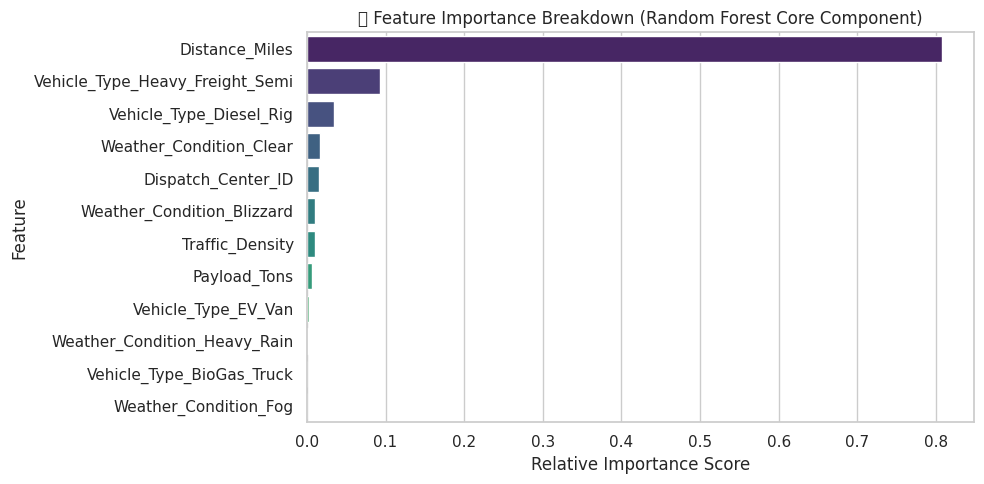

In [7]:
# Extract the trained preprocessing step and the random forest model from our pipeline
preprocessor_fitted = production_pipeline.named_steps['preprocessor']
rf_model_fitted = production_pipeline.named_steps['ensemble'].named_estimators_['rf']

# Reconstruct feature names after one-hot encoding transformations
encoded_cat_features = preprocessor_fitted.named_transformers_['low_cat'].get_feature_names_out(low_card_cat).tolist()
all_feature_names = num_features + encoded_cat_features + high_card_cat

# Extract importances
importances = rf_model_fitted.feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("🌳 Feature Importance Breakdown (Random Forest Core Component)")
plt.xlabel("Relative Importance Score")
plt.tight_layout()
plt.show()

## 🛡️ Section 7: Enterprise Guardrails & Automated Data Validation
In a production environment, upstream data streams often break. If a faulty sensor sends impossible data (such as a negative travel distance or missing columns), a standard model will break or output nonsense. 

This section builds defensive corporate guardrails. It runs automated logical asset checks that flag data anomalies instantly, ensuring the pipeline remains secure and reliable.

In [8]:
def validate_production_data(input_df: pd.DataFrame):
    """Executes defensive data engineering structural checks."""
    try:
        # Check 1: Ensure all critical columns exist
        required_cols = ['Distance_Miles', 'Payload_Tons', 'Traffic_Density', 'Vehicle_Type', 'Weather_Condition']
        for col in required_cols:
            assert col in input_df.columns, f"🚨 Critical Failure: Missing column {col}"
        
        # Check 2: Validate logical boundaries on processed data (ignoring NaNs for now)
        assert input_df['Distance_Miles'].dropna().min() >= 0, "🚨 Data Anomaly: Negative distance values detected!"
        assert input_df['Payload_Tons'].dropna().min() >= 0, "🚨 Data Anomaly: Negative payload capacity detected!"
        
        print("🛡️ Automated Guardrails: Data structure and boundaries passed validation checks.")
    except AssertionError as error:
        print(error)
        raise

# Run validation check on our test partition as a proof of concept
validate_production_data(X_test)

🛡️ Automated Guardrails: Data structure and boundaries passed validation checks.


## 💾 Section 8: Production Export & Deployment Readiness
The final stage of the project lifecycle packages the entire operational pipeline—the data cleaners, encoders, and machine learning models—into a single, compact binary file. This file is fully optimized and ready to be handed to a cloud engineer to plug directly into a website, a mobile application, or an enterprise internal dashboard.

In [9]:
import joblib

# Serialize the complete production pipeline architecture
model_filename = "ecoroute_stacking_pipeline.pkl"
joblib.dump(production_pipeline, model_filename)

print(f"📦 Production artifact successfully saved as: '{model_filename}'")
print("🚀 Pipeline is fully prepared for cloud deployment!")

📦 Production artifact successfully saved as: 'ecoroute_stacking_pipeline.pkl'
🚀 Pipeline is fully prepared for cloud deployment!
